# Story 02 — Cross-Run Ranking & Gate 3 Recommendation

Aggregates all iteration results into a trade-off map and recommendation.


In [1]:
import sys, json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

STORY_ROOT = Path(".").resolve()
sys.path.insert(0, str(STORY_ROOT))
from knn_lib import ITERATIONS_DIR, RESULTS_DIR, TVD_THRESHOLD, KS_THRESHOLD, PASS_RATE_TARGET

ranking = pd.read_csv(RESULTS_DIR / "experiment_ranking.csv")
ranking


,folder,name,k_anonymity,k_neighbors,cat_gen_method,num_gen_method,target_gen_method,scaler_method,num_weight,cat_weight,...,ks_pass_rate,mean_tvd,mean_ks,mean_corr_drift,f1_baseline,f1_synthetic,exact_match_rate,overall_pass,composite_score,rank
0,08_scaler-robust_knn15_cat-weighted-mode_num-i...,Scaler Robust,5,15,weighted_mode,interpolation,probability,robust,1.0,1.0,...,1.00,0.0073,0.0271,0.020535,0.2923,0.2277,0.0,False,2.560774,1
1,11_dist-cat-heavy_knn15_cat-weighted-mode_num-...,Dist Cat Heavy,5,15,weighted_mode,interpolation,probability,standard,0.5,2.0,...,1.00,0.0000,0.0282,0.021504,0.2923,0.1176,0.0,False,2.180556,2
2,09_scaler-minmax_knn15_cat-weighted-mode_num-i...,Scaler Minmax,5,15,weighted_mode,interpolation,probability,minmax,1.0,1.0,...,1.00,0.0267,0.0249,0.022315,0.2923,0.0399,0.0,False,1.920974,3
3,06_cat-mode_knn15_cat-mode_num-interpolation_s...,Cat Mode,5,15,mode,interpolation,probability,standard,1.0,1.0,...,1.00,0.0831,0.0211,0.019665,0.2923,0.1587,0.0,False,1.827085,4
4,01_baseline_knn15_cat-weighted-mode_num-interp...,Baseline,5,15,weighted_mode,interpolation,probability,standard,1.0,1.0,...,1.00,0.0804,0.0211,0.019665,0.2923,0.1500,0.0,False,1.813321,5
5,04_knn05_knn05_cat-weighted-mode_num-interpola...,Knn05,5,5,weighted_mode,interpolation,probability,standard,1.0,1.0,...,1.00,0.0764,0.0182,0.019961,0.2923,0.1486,0.0,False,1.808272,6
6,02_knn10_knn10_cat-weighted-mode_num-interpola...,Knn10,5,10,weighted_mode,interpolation,probability,standard,1.0,1.0,...,1.00,0.0779,0.0193,0.021436,0.2923,0.1268,0.0,False,1.723681,7
7,05_cat-probability_knn15_cat-probability_num-i...,Cat Probability,5,15,probability,interpolation,probability,standard,1.0,1.0,...,1.00,0.0864,0.0209,0.019918,0.2923,0.1080,0.0,False,1.656423,8
8,03_knn25_knn25_cat-weighted-mode_num-interpola...,Knn25,5,25,weighted_mode,interpolation,probability,standard,1.0,1.0,...,1.00,0.0796,0.0223,0.019883,0.2923,0.1045,0.0,False,1.640069,9
9,13_seed-123_knn15_cat-weighted-mode_num-interp...,Seed 123,5,15,weighted_mode,interpolation,probability,standard,1.0,1.0,...,1.00,0.0804,0.0216,0.021024,0.2923,0.0993,0.0,False,1.624049,10


## AC2 — Quality Metrics Aggregate


In [2]:
print("=== Primary metrics (Story 02 targets) ===")
print(f"TVD target: >{PASS_RATE_TARGET:.0%} columns with TVD < {TVD_THRESHOLD}")
print(f"KS target:  >{PASS_RATE_TARGET:.0%} columns with KS  < {KS_THRESHOLD}")
print()
for _, row in ranking.iterrows():
    tvd_ok = "PASS" if row["tvd_pass_rate"] >= PASS_RATE_TARGET else "FAIL"
    ks_ok = "PASS" if row["ks_pass_rate"] >= PASS_RATE_TARGET else "FAIL"
    print(f"{row['rank']:2d}. {row['folder'][:45]:45s} TVD={row['tvd_pass_rate']:.0%} [{tvd_ok}] KS={row['ks_pass_rate']:.0%} [{ks_ok}] runtime={row['runtime_sec']}s")


=== Primary metrics (Story 02 targets) ===
TVD target: >85% columns with TVD < 0.1
KS target:  >85% columns with KS  < 0.1

 1. 08_scaler-robust_knn15_cat-weighted-mode_num- TVD=100% [PASS] KS=100% [PASS] runtime=19.112s
 2. 11_dist-cat-heavy_knn15_cat-weighted-mode_num TVD=100% [PASS] KS=100% [PASS] runtime=19.357s
 3. 09_scaler-minmax_knn15_cat-weighted-mode_num- TVD=100% [PASS] KS=100% [PASS] runtime=19.063s
 4. 06_cat-mode_knn15_cat-mode_num-interpolation_ TVD=50% [FAIL] KS=100% [PASS] runtime=19.475s
 5. 01_baseline_knn15_cat-weighted-mode_num-inter TVD=50% [FAIL] KS=100% [PASS] runtime=17.875s
 6. 04_knn05_knn05_cat-weighted-mode_num-interpol TVD=50% [FAIL] KS=100% [PASS] runtime=18.191s
 7. 02_knn10_knn10_cat-weighted-mode_num-interpol TVD=50% [FAIL] KS=100% [PASS] runtime=19.082s
 8. 05_cat-probability_knn15_cat-probability_num- TVD=50% [FAIL] KS=100% [PASS] runtime=19.216s
 9. 03_knn25_knn25_cat-weighted-mode_num-interpol TVD=50% [FAIL] KS=100% [PASS] runtime=19.514s
10. 13_se

## Area 4 — Trade-off Mapping


/tmp/ipykernel_316329/4166974122.py:18: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


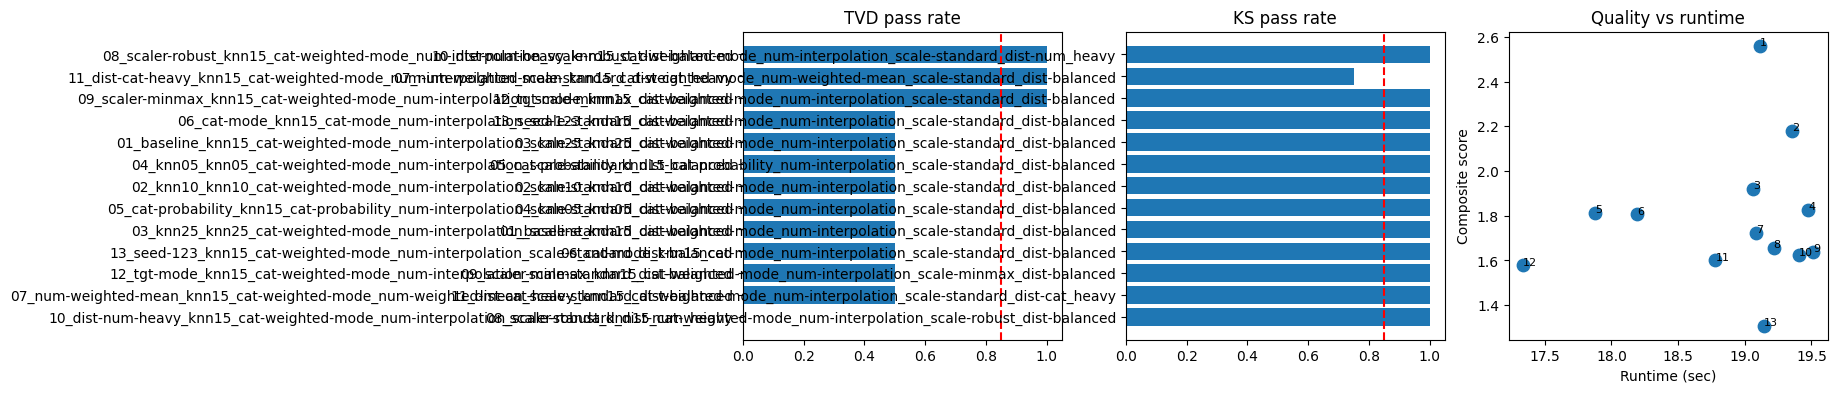

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].barh(ranking["folder"], ranking["tvd_pass_rate"])
axes[0].axvline(PASS_RATE_TARGET, color="r", linestyle="--", label="85% target")
axes[0].set_title("TVD pass rate")
axes[0].invert_yaxis()

axes[1].barh(ranking["folder"], ranking["ks_pass_rate"])
axes[1].axvline(PASS_RATE_TARGET, color="r", linestyle="--")
axes[1].set_title("KS pass rate")

axes[2].scatter(ranking["runtime_sec"], ranking["composite_score"], s=80)
for _, r in ranking.iterrows():
    axes[2].annotate(str(int(r["rank"])), (r["runtime_sec"], r["composite_score"]), fontsize=8)
axes[2].set_xlabel("Runtime (sec)")
axes[2].set_ylabel("Composite score")
axes[2].set_title("Quality vs runtime")
plt.tight_layout()
plt.show()


## Per-iteration scorecard detail


In [4]:
scorecards = []
for folder in sorted(ITERATIONS_DIR.iterdir()):
    sc_path = folder / "scorecard.csv"
    if sc_path.exists():
        sc = pd.read_csv(sc_path)
        sc["iteration"] = folder.name
        scorecards.append(sc)
all_sc = pd.concat(scorecards, ignore_index=True)
all_sc.pivot_table(index="iteration", columns="metric", values="pass", aggfunc="first")


metric,F1>=80% baseline,ks_pass_rate>=0.85,mean_KS<0.10,mean_corr_drift<0.05,recovery_rate,replaced_exact_match_rate<0.001,tvd_pass_rate>=0.85
iteration,,,,,,,
01_baseline_knn15_cat-weighted-mode_num-interpolation_scale-standard_dist-balanced,False,True,True,True,True,True,False
02_knn10_knn10_cat-weighted-mode_num-interpolation_scale-standard_dist-balanced,False,True,True,True,True,True,False
03_knn25_knn25_cat-weighted-mode_num-interpolation_scale-standard_dist-balanced,False,True,True,True,True,True,False
04_knn05_knn05_cat-weighted-mode_num-interpolation_scale-standard_dist-balanced,False,True,True,True,True,True,False
05_cat-probability_knn15_cat-probability_num-interpolation_scale-standard_dist-balanced,False,True,True,True,True,True,False
06_cat-mode_knn15_cat-mode_num-interpolation_scale-standard_dist-balanced,False,True,True,True,True,True,False
07_num-weighted-mean_knn15_cat-weighted-mode_num-weighted-mean_scale-standard_dist-balanced,False,False,True,True,True,True,False
08_scaler_robust,False,True,True,True,True,True,True
09_scaler-minmax_knn15_cat-weighted-mode_num-interpolation_scale-minmax_dist-balanced,False,True,True,True,True,True,True


## Gate 3 Recommendation


In [5]:
best = ranking.iloc[0]
n_pass = ranking["overall_pass"].sum()
n_total = len(ranking)

recommendation = f"""
# Gate 3 — Story 02 Recommendation (Bank Churn Demo)

## Decision: {"Go — single production configuration" if n_pass >= n_total * 0.7 else "Profile-driven policy recommended" if n_pass > 0 else "No-Go"}

## Top-ranked configuration
- **Folder:** {best['folder']}
- **K (anonymity):** {int(best['k_anonymity'])}
- **K (neighbours):** {int(best['k_neighbors'])}
- **Categorical generation:** {best['cat_gen_method']}
- **Numerical generation:** {best['num_gen_method']}
- **Scaler:** {best['scaler_method']}
- **Distance weights:** num={best['num_weight']}, cat={best['cat_weight']}

## Evidence
- TVD pass rate: {best['tvd_pass_rate']:.1%} (target >85%)
- KS pass rate:  {best['ks_pass_rate']:.1%} (target >85%)
- Mean KS: {best['mean_ks']:.4f}
- F1 synthetic / baseline: {best['f1_synthetic']:.4f} / {best['f1_baseline']:.4f}
- Runtime: {best['runtime_sec']}s | Memory peak: {best['peak_memory_mb']} MB
- Overall pass: {best['overall_pass']}
- Iterations passing all checks: {n_pass}/{n_total}

## High-cardinality note
Bank churn categoricals (country, gender) are low-cardinality. High-cardinality policy
should be re-validated on production partner dataset with wider cardinality bands.

## Limitations
- Demo dataset, not za-dev production partner data
- k-anonymity uses generalized QI bins for numerics
- Single-run per config (seed stability tested in iteration 10)
"""

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
out_path = RESULTS_DIR / "gate3_recommendation.md"
out_path.write_text(recommendation.strip())
print(recommendation)
print(f"\nSaved: {out_path}")



# Gate 3 — Story 02 Recommendation (Bank Churn Demo)

## Decision: No-Go

## Top-ranked configuration
- **Folder:** 08_scaler_robust
- **K (anonymity):** 5
- **K (neighbours):** 15
- **Categorical generation:** weighted_mode
- **Numerical generation:** interpolation
- **Scaler:** robust
- **Distance weights:** num=1.0, cat=1.0

## Evidence
- TVD pass rate: 100.0% (target >85%)
- KS pass rate:  100.0% (target >85%)
- Mean KS: 0.0271
- F1 synthetic / baseline: 0.2277 / 0.2923
- Runtime: 19.112s | Memory peak: 5.82 MB
- Overall pass: False
- Iterations passing all checks: 0/13

## High-cardinality note
Bank churn categoricals (country, gender) are low-cardinality. High-cardinality policy
should be re-validated on production partner dataset with wider cardinality bands.

## Limitations
- Demo dataset, not za-dev production partner data
- k-anonymity uses generalized QI bins for numerics
- Single-run per config (seed stability tested in iteration 10)


Saved: /home/neosoft/KNN_demo/story02